# Crypto perpetuals: the baseline that turns a ranking into a book

The model notebooks produced rankings. At each eight-hour funding timestamp, each configuration
scores the contracts it can see and orders them. A ranking is not a portfolio, and nothing so
far says what a reader would have earned holding one.

This notebook builds the crudest portfolio that a ranking supports and runs it. An **entry
rule** turns the scores at one timestamp into a set of positions - take the five highest-scored
contracts long and the five lowest short, say - and every position gets the same weight. Equal
weight is deliberate. It is the one sizing choice that contributes no information of its own, so
a difference between two configurations here is a difference between their rankings and nothing
else. [`14_portfolio_management`](14_portfolio_management.ipynb) is where sizing starts to vary.

**Funding is the reason this case study exists, and it is settled inside the run.** A perpetual
future never expires, so no delivery date forces its price towards spot. The exchange applies a
**funding rate** instead: every eight hours, whoever is long pays whoever is short an amount
proportional to the gap between the perpetual and the index, and when the gap is negative the
payment runs the other way. That is a cash flow the holder receives or pays whatever the price
does. A position can pay while its price prediction is wrong, and a price-only equity curve is
therefore not the return on a perpetual position - it is a different quantity. The backtest
boundary settles the official rate against the position carried into each timestamp, before any
fill at that same timestamp, and the rates it used are part of what identifies the result.

**Nothing is selected here.** Every declared configuration gets a baseline, the results are
registered, and the ranking of one against another is read in
[`19_strategy_analysis`](19_strategy_analysis.ipynb).

**Learning objectives.** By the end of this notebook you will be able to:

- State, for one strategy, the moment the decision is taken, the moment it is filled, how long
  the position is held, and when the next decision is allowed, and check that the four agree
  with the horizon the label was built on.
- Say why a long-short rule that asks for ten contracts a side cannot be run on a universe of
  nineteen, and read which members of a declared grid the shared selector dropped.
- Run every member of a frozen prediction population through one entry rule and have each
  result registered with the funding settlements that produced it.
- Recognise an equal-weight backtest as the reference every later sizing, cost and risk variant
  is measured against, rather than as a candidate in its own right.

**Book reference**: Chapter 16 (Strategy Simulation).

**Prerequisites**: the model notebooks [`06_linear`](06_linear.ipynb) through
[`10_dl_tcn`](10_dl_tcn.ipynb) have registered their complete validation prediction populations.

**What it writes**: one `stage='signal'` backtest per prediction set and entry rule, in
`run_log/registry.db`, grouped into one immutable population per entry rule and one candidate
set per label. [`14_portfolio_management`](14_portfolio_management.ipynb) reads those candidate
sets.

In [1]:
"""Run the equal-weight baseline for every declared crypto perpetuals prediction set."""

from datetime import UTC, timedelta

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.crypto_perps_funding.research_workflow import (
    ALL_LABELS,
    freeze_official_model_population,
    preview_prediction_candidates,
)
from case_studies.research import (
    CandidateSet,
    Result,
    candidate_set_supersedes,
    open_study,
    population_supersedes,
    run_backtests,
)
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    get_rebalance_step,
    load_backtest_prices_for,
)
from case_studies.utils.coverage import CoverageError, check_prediction_coverage
from case_studies.utils.sweep_config import get_entry_schemes_for
from utils.artifact_specs import load_setup_config
from utils.paths import get_case_study_dir
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
POPULATION_SUFFIX = "v1"
# The generation of `crypto-validation-predictions-v1` this run replaces, when it replaces one.
# Re-declaring a population under a name that already exists with different members is refused
# unless the run says which generation it supersedes: the model notebooks each take the same
# parameter, and this one publishes the case-wide list they feed. Left empty on a first run and
# on any re-run whose membership is unchanged; the refusal names the hash to put here.
SUPERSEDES_POPULATION: str = ""
# The baseline sweep publishes one population per (label, entry rule), so a run that changes
# them cannot name the generation it retires with a single value the way the model population
# can. Keyed by population name, and every entry declares `live` rather than a hash: this run
# intends to extend whatever generation each name currently publishes, which is a property of
# the run and does not decay, where a hash is a committed constant against a value the registry
# moves on every publish. A name with no generation yet resolves to nothing and publishes
# generation one, so listing all twelve costs nothing.
SUPERSEDES_BACKTESTS: dict[str, str] = {
    "crypto-signal-fwd_ret_8h-ew_top3-v1": "live",
    "crypto-signal-fwd_ret_8h-ew_top5-v1": "live",
    "crypto-signal-fwd_ret_8h-quintile_ls-v1": "live",
    "crypto-signal-fwd_ret_24h-ew_top3-v1": "live",
    "crypto-signal-fwd_ret_24h-ew_top5-v1": "live",
    "crypto-signal-fwd_ret_24h-quintile_ls-v1": "live",
    "crypto-signal-fwd_dir_8h-ew_top3-v1": "live",
    "crypto-signal-fwd_dir_8h-ew_top5-v1": "live",
    "crypto-signal-fwd_dir_8h-quintile_ls-v1": "live",
    "crypto-signal-fwd_dir_8h_3c-ew_top3-v1": "live",
    "crypto-signal-fwd_dir_8h_3c-ew_top5-v1": "live",
    "crypto-signal-fwd_dir_8h_3c-quintile_ls-v1": "live",
}
# The folds a reduced upstream run actually fitted. Empty on a canonical run, which is measured
# against every fold `config/setup.yaml` declares. A preview that reduced to a subset has no rows
# for the rest by construction, and the coverage gate below would report the reduction itself as
# an incomplete prediction set - so the run states the subset it declared, and the gate still
# compares against setup.yaml's windows rather than against whatever the frame happens to hold.
PREVIEW_FOLDS: list[int] = []
# The candidate set each label hands downstream is a third generation-bearing name, one per
# label. Keyed and declared the same way, and for the same reason.
SUPERSEDES_CANDIDATES: dict[str, str] = {
    "crypto-signal-fwd_ret_8h": "live",
    "crypto-signal-fwd_ret_24h": "live",
    "crypto-signal-fwd_dir_8h": "live",
    "crypto-signal-fwd_dir_8h_3c": "live",
}
# How many prediction sets a preview run backtests per label. A preview reads the predictions
# its own model notebooks wrote into its workspace, and what it is proving is that the chain
# executes rather than that the sweep is wide, so it is capped instead of taking whatever the
# reduced fits happened to leave. Read only on a preview run; a canonical run backtests the
# declared population and nothing else.
PREVIEW_MAX_PREDICTIONS = 4

In [3]:
study = open_study(
    "crypto_perps_funding", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)
setup = load_setup_config("crypto_perps_funding")
labels = list(LABELS) if LABELS else list(ALL_LABELS)

## 1. The population this notebook backtests

A **population** is a named, immutable list of results, written down before the work that
produces them starts. The model notebooks each published one; the call below re-derives the
complete case-wide list from the training menus and records it under one name, so that what
follows is measured against a declaration rather than against whatever the registry happens to
contain. If a configuration is declared and missing, or present and incomplete, the check two
cells down fails here rather than producing a baseline over a silently smaller set.

Freezing is a canonical-run step. A preview run against a private workspace backtests the
predictions its own model notebooks wrote there; it does not read the released population and
does not redeclare it.

In [4]:
CANONICAL_RUN = EXECUTION_TIER == "canonical" and not WORKSPACE
if PREVIEW_FOLDS and CANONICAL_RUN:
    raise ValueError(
        "PREVIEW_FOLDS narrows the coverage gate and a canonical run may not narrow it: "
        "the published prediction sets must cover every fold setup.yaml declares"
    )
if CANONICAL_RUN:
    prediction_population = freeze_official_model_population(
        study, supersedes=SUPERSEDES_POPULATION or None
    )
    print(
        f"declared population {prediction_population.name}: "
        f"{len(prediction_population.members)} prediction sets"
    )

declared population crypto-validation-predictions-v1: 677 prediction sets


The catalog is what gets backtested, and on a canonical run it is **the declared population
read back**, not the registry filtered down to it. The distinction is the whole point of
freezing: a query returns whatever is registered under a set of predicates, and the registry
is immutable, so a superseded generation's rows are still there and still `complete`. Filtering
by `split`, `label` and `complete` therefore returns both generations, and a sweep over both
ranks a retired identity against a live one and carries whichever wins into every stage
downstream. Reading the population back cannot do that: it is a fixed list of hashes, declared
before this notebook ran.

The membership check is the other half. A declared member with no registry row means the
population names something the model notebooks never produced, and that has to fail here rather
than produce a baseline over a silently smaller set.

In [5]:
if CANONICAL_RUN:
    declared = list(prediction_population.members)
    catalog = (
        study.predictions.table()
        .filter(pl.col("prediction_hash").is_in(declared))
        .filter(pl.col("label").is_in(labels))
    )
    # Every declared member has a registry row, asked of the declaration and not of the catalog.
    # The catalog is narrowed to the requested labels, so comparing against it reports the other
    # labels' members as missing on a narrowed run; suppressing the check on a narrowed run
    # instead lets a requested label's member go missing in silence, which is what it exists to
    # catch. Asked this way it holds either way, because a population member that nothing
    # registered is a declaration the model notebooks never produced.
    registered = set(
        study.predictions.table()
        .filter(pl.col("prediction_hash").is_in(declared))
        .get_column("prediction_hash")
        .to_list()
    )
    absent = set(declared) - registered
    if absent:
        raise RuntimeError(
            f"{len(absent)} declared population members have no registry row, "
            f"first {sorted(absent)[0]}"
        )
    if catalog.filter(pl.col("split") != "validation").height:
        raise RuntimeError("the declared model population contains a non-validation member")
else:
    catalog = preview_prediction_candidates(study, labels=labels, limit=PREVIEW_MAX_PREDICTIONS)
if catalog.is_empty():
    raise RuntimeError("no validation prediction sets to backtest")

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("the validation prediction catalog contains incomplete members")
if catalog.get_column("identity_status").n_unique() != 1:
    raise RuntimeError("the validation prediction catalog mixes identity versions")

catalog.group_by("family", "label").agg(
    configurations=pl.col("config_name").n_unique(),
    prediction_sets=pl.len(),
    checkpoints=pl.col("checkpoint_value").n_unique(),
).sort("family", "label")

family,label,configurations,prediction_sets,checkpoints
str,str,u32,u32,u32
"""deep_learning""","""fwd_ret_24h""",2,40,20
"""deep_learning""","""fwd_ret_8h""",3,60,20
"""gbm""","""fwd_dir_8h""",5,50,10
"""gbm""","""fwd_dir_8h_3c""",5,50,10
"""gbm""","""fwd_ret_24h""",15,150,10
…,…,…,…,…
"""linear""","""fwd_ret_8h""",28,28,1
"""tabular_dl""","""fwd_dir_8h""",3,24,8
"""tabular_dl""","""fwd_dir_8h_3c""",3,24,8


Gradient boosting contributes many more prediction sets than configurations because a boosted
model is scored at ten points along its own training, and each of those checkpoints is a
separate configuration to be backtested rather than a variant of one. A linear fit has a single
state and so contributes one prediction set per configuration.

## 2. The decision clock

Four moments define a trade, and a backtest is only meaningful when they line up with the label
the model was fitted on. For this case study `config/setup.yaml` declares them in the `decision`
block:

- **The information cutoff** is the pre-funding snapshot. Features are computed from data
  observable strictly before the settlement, so nothing the model reads is contemporaneous with
  the payment it is trading around.
- **The fill** is at the funding timestamp itself. The engine executes at that bar rather than
  the next one, which is what makes the position the funding is charged against the position the
  decision asked for.
- **The holding period** is the label's own horizon: eight hours for the three eight-hour
  labels, twenty-four for `fwd_ret_24h`.
- **The next decision** comes one *rebalance step* later. A step is counted in slots of the
  eight-hour funding schedule, and it is what keeps holding periods from overlapping: a
  twenty-four-hour position cannot be re-decided at the next settlement without the second trade
  sitting inside the first one's window, so `fwd_ret_24h` advances three slots and the
  eight-hour labels advance one.

The cell below reads the decision times out of the prediction sets, locates each one on the
panel's settlement index, and reports how far apart consecutive decisions are.

**It reports rather than adjudicates, and the reason is that the only thing it could adjudicate
was wrong.** It used to require the advance to equal `step` exactly. Of the two directions that
reading refuses, one is unreachable and the other is not this cell's to judge:

- *Closer together than `step`* is the direction that would corrupt a result, because two
  positions whose holding periods overlap count the same return twice. It cannot occur here.
  `decision_timeline` returns unique (fold, timestamp) pairs, so the slots inside a fold are
  strictly increasing integers, and the distance between slot *i* and slot *i + step* is at
  least `step` whatever the model did. Whether the engine honours the step it was handed is a
  question about `get_rebalance_step`'s consumer, not about the keys the predictions were
  written at, and nothing in this cell can see it.
- *Further apart than `step`* asserts that the family predicted at every settlement the panel
  holds. That is a claim about completeness, it is made properly one cell up, and it is false by
  construction for a whole family - which is the paragraph after next.

**A step apart on the panel's own clock, not eight hours apart on the calendar.** The two
readings agree wherever the panel is contiguous and diverge exactly where it is not, and this
panel is not: `features/financial.parquet` carries a 57-day hole opening 2021-08-27, an outage
in the premium-index feed. Locating each decision on the panel's settlement index rather than on
the calendar is also what refuses a decision at a timestamp the panel does not hold at all,
which `holding_slots` raises on before it measures anything.

**What this cell deliberately does not assert is that a decision exists at every settlement the
panel holds.** A sequence model predicts only where a full lookback of history exists and the
window is observed densely enough to be read as a window, so its eligible keys are not every
(entity, date) in the fold - which is what
`deep_learning.py::locked_sequence_expected_keys` says in as many words, and what
`utils/sequence_dataset.py::GAP_POLICY_ID` names and versions. Requiring the advance to equal
`step` asserted that a family's eligibility equals the whole panel grid: a tautology for the
cross-sectional families, and false by construction for the sequence ones.

The claim it was reaching for is already made, one cell up and against a better authority.
`complete` is not a loose word here: `registry/completeness.py` marks a member complete only
when the digest of the keys it was actually written at equals the digest of the keys its own
configuration declared it eligible for, with no duplicate, missing, extra, null or non-finite
score. A model that predicted on a wider stride than it could have therefore fails
the cell above, not this one, and it fails naming the keys it missed rather than a settlement
count. Restating a weaker version of that here could only ever fire when the weaker version was
the one that was wrong.

It still cannot read one set and let it speak for the label.
`prediction_coverage.actual_key_digest` records the keys each member was written at: members
sharing a digest were predicted at the same keys, and each distinct digest is a separate grid
checked on its own. This case study carries more than one per label - the sequence models write a
sparser panel than the cross-sectional ones
over the same decision times - so the table below reports each grid's own coverage of the panel,
and `panel_settlements_skipped` is where that sparsity is visible rather than tolerated in
silence.

In [6]:
def decision_grids(label: str) -> pl.DataFrame:
    """The distinct key sets one label was predicted at, with a representative member of each."""
    members = catalog.filter(pl.col("label") == label)
    if members.get_column("decision_key_digest").null_count():
        blank = members.filter(pl.col("decision_key_digest").is_null())
        raise RuntimeError(
            f"{label}: {blank.height} of {members.height} prediction sets record no decision-key "
            f"digest, so the keys they were written at are unknown and cannot be checked; "
            f"first {blank.item(0, 'prediction_hash')}"
        )
    return (
        members.group_by("decision_key_digest")
        .agg(
            prediction_sets=pl.len(),
            families=pl.col("family").unique().sort(),
            reference=pl.col("prediction_hash").min(),
        )
        .sort("prediction_sets", "decision_key_digest", descending=[True, False])
    )

In [7]:
def declared_gap_policy(reference: str) -> str | None:
    """The gap policy a grid's members were fitted under, or None if they declare none.

    A sequence family writes `computation.preprocessing.gap_policy` into its training spec, a
    named and versioned rule saying which windows it was allowed to read; the cross-sectional
    families write no preprocessing block at all. Reading the declaration rather than testing the
    family name is what keeps this correct when a fifth family arrives, and the value is carried
    in the spec the fit was registered under, so it cannot drift from the run it describes.
    """
    spec = Result.open(study, reference, include_preview=not CANONICAL_RUN).spec()
    training_hash = spec.get("training_hash")
    if not training_hash:
        return None
    training = Result.open(study, training_hash, include_preview=not CANONICAL_RUN).spec()
    return ((training.get("computation") or {}).get("preprocessing") or {}).get("gap_policy")


def decision_timeline(prediction_hash: str) -> pl.DataFrame:
    """Return the distinct fold and decision timestamps one prediction set was written at."""
    return (
        Result.open(study, prediction_hash, include_preview=not CANONICAL_RUN)
        .load()
        .select("fold", "timestamp")
        .unique()
        .sort("fold", "timestamp")
    )

In [8]:
def decision_clock() -> pl.DataFrame:
    """Every settlement the feature panel holds, numbered. The clock decisions are read on.

    The panel rather than the label file: a model decides where it has features, and the two
    differ here by the 57-day premium-index outage, which the label file does not have because a
    forward return is computed from prices alone.
    """
    panel = (
        pl.read_parquet(
            get_case_study_dir("crypto_perps_funding") / "features" / "financial.parquet"
        )
        .select("timestamp")
        .unique()
        .sort("timestamp")
    )
    return panel.with_row_index("slot")


CLOCK = decision_clock()
CLOCK_DTYPE = CLOCK.schema["timestamp"]


def on_clock_dtype(frame: pl.DataFrame) -> pl.DataFrame:
    """One timestamp dtype, so a join on it cannot silently match nothing.

    200 of this case study's 778 prediction artifacts - every `deep_learning` set - carry a
    microsecond timestamp where the other 578 carry milliseconds, both UTC. The sequence path
    round-trips the frame through pandas, whose datetime64[ns] comes back as `us` rather than
    the `ms` the panel is written at. The instants are identical.

    **The divergence is deliberate and must not be unified at the source.**
    `artifact_digest.value_digest` is sensitive to the time unit and insensitive to the zone -
    the same two instants digest to `1cc433614b1d12f9` at `ms` and `963d16e17fb4eb7f` at `us`,
    and identically whether or not they carry UTC. `computation.expected_prediction_keys.digest`
    is taken over this column, so rewriting the stored unit would move `training_hash` for every
    registered sequence run, and `_MIGRATABLE_FIELDS` covers only `computation.source_identity`.
    Reconciling a cosmetic difference by re-keying a registry is the most expensive mistake
    available here.

    So the normalization belongs at each join site, which is what this is. It also stamps a naive
    value as the UTC it is rather than dropping the zone from everything, and the replace comes
    before the cast because casting a naive column to a zoned dtype converts it instead of
    stamping it. No artifact is naive today - `_timestamps_as_utc` closed the zone half on
    2026-08-28, deliberately leaving the unit half alone - and the branch stays because the
    pandas round-trip is what produced the zone loss in the first place.
    """
    dtype = frame.schema["timestamp"]
    if dtype == CLOCK_DTYPE:
        return frame
    stamp = pl.col("timestamp")
    if getattr(dtype, "time_zone", None) is None:
        stamp = stamp.dt.replace_time_zone("UTC")
    return frame.with_columns(stamp.cast(CLOCK_DTYPE))

In [9]:
def holding_slots(timeline: pl.DataFrame, step: int) -> list[int]:
    """The distinct clock distances between decisions `step` positions apart inside a fold."""
    located = on_clock_dtype(timeline).join(CLOCK, on="timestamp", how="left")
    if located.get_column("slot").null_count():
        stray = located.filter(pl.col("slot").is_null()).get_column("timestamp")
        raise RuntimeError(
            f"{stray.len()} decisions sit at timestamps the feature panel does not hold, "
            f"first {stray.min()}"
        )
    return (
        located.sort("fold", "slot")
        .with_columns(pl.col("slot").shift(-step).over("fold").alias("exit"))
        .drop_nulls("exit")
        .select((pl.col("exit") - pl.col("slot")).alias("advanced"))
        .get_column("advanced")
        .unique()
        .sort()
        .to_list()
    )


def skipped_settlements(timeline: pl.DataFrame) -> int:
    """Settlements inside a fold's own span that the panel holds and this grid does not decide at.

    `holding_slots` returns the distinct advances, which says whether a gap exists and not how
    much of the panel it costs. This totals it, so a grid's sparsity is a number in the table
    rather than something a reader has to infer from a list of advances.

    Counted as span minus decisions per fold, and deliberately not from the advances: summing
    `advance - step` over consecutive pairs counts one missing settlement `step` times, so an
    `fwd_ret_24h` grid at `step` 3 would report three times the hole it has. This takes no step
    at all, because the question is how many panel settlements are absent, which the rebalance
    cadence does not enter.

    Interior to each fold. A fold's decisions beginning late or ending early is a different
    claim, and the coverage report below is what makes it: those appear there as
    `missing_sessions` against the declared window, which a span measured from the grid's own
    first and last decision cannot see.
    """
    located = on_clock_dtype(timeline).join(CLOCK, on="timestamp", how="left")
    per_fold = located.group_by("fold").agg(
        (pl.col("slot").max() - pl.col("slot").min() + 1 - pl.len()).alias("skipped")
    )
    return int(per_fold.get_column("skipped").sum())


def holding_periods(timeline: pl.DataFrame, step: int) -> list[timedelta]:
    """The distinct calendar gaps between decisions `step` slots apart, for the table below."""
    return (
        timeline.with_columns(pl.col("timestamp").shift(-step).over("fold").alias("exit"))
        .drop_nulls("exit")
        .select((pl.col("exit") - pl.col("timestamp")).alias("held"))
        .get_column("held")
        .unique()
        .sort()
        .to_list()
    )


def _utc(moment):
    """One zone for the summary below, whatever the artifact it came from carried.

    The counts and the reason the units differ are on `on_clock_dtype` above; this is the same
    normalization for a scalar the table prints rather than a column a join reads. A naive value
    is read as the UTC it is rather than the zone being dropped from everything, which would
    hide the difference instead of resolving it.
    """
    return moment.replace(tzinfo=UTC) if moment.tzinfo is None else moment.astimezone(UTC)

In [10]:
decision = setup["decision"]
intervals = []
for label in labels:
    step = get_rebalance_step("crypto_perps_funding", label)
    horizon = study.labels.get(label).definition.horizon.upper()
    if not horizon.endswith("H") or not horizon.removesuffix("H").isdigit():
        raise RuntimeError(f"unsupported crypto label horizon {horizon!r}")
    for grid in decision_grids(label).iter_rows(named=True):
        timeline = decision_timeline(grid["reference"])
        advanced = holding_slots(timeline, step)
        intervals.append(
            {
                "label": label,
                "grid": grid["decision_key_digest"][:12],
                "families": "/".join(grid["families"]),
                "prediction_sets": grid["prediction_sets"],
                "information_cutoff": decision["snapshot"],
                "fill": decision["execution_delay"],
                "outcome_horizon": horizon,
                "rebalance_step_slots": step,
                # The calendar gaps the clock check just accepted. One value on a contiguous
                # stretch of the panel; a second, larger one wherever the panel has a hole, which
                # is the difference between the two readings shown rather than described.
                "calendar_gaps": [str(gap) for gap in holding_periods(timeline, step)],
                "decision_times": timeline.height,
                # Settlements the panel holds that this grid does not decide at. Zero for the
                # cross-sectional families. Non-zero for a sequence family wherever its lookback
                # cannot be filled, which is a property of the panel and not of the model, and is
                # printed here so a Sharpe compared across families is compared knowing it.
                "panel_settlements_skipped": skipped_settlements(timeline),
                "first_decision": _utc(timeline.get_column("timestamp").min()),
                "last_decision": _utc(timeline.get_column("timestamp").max()),
            }
        )
pl.DataFrame(intervals).sort("label", "grid")

label,grid,families,prediction_sets,information_cutoff,fill,outcome_horizon,rebalance_step_slots,calendar_gaps,decision_times,panel_settlements_skipped,first_decision,last_decision
str,str,str,i64,str,str,str,i64,list[str],i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]"
"""fwd_dir_8h""","""d1141645bdee""","""gbm/linear/tabular_dl""",86,"""pre_funding_timestamp""","""at_funding_timestamp""","""8H""",1,"[""8:00:00""]",2189,0,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""fwd_dir_8h_3c""","""d1141645bdee""","""gbm/linear/tabular_dl""",87,"""pre_funding_timestamp""","""at_funding_timestamp""","""8H""",1,"[""8:00:00""]",2189,0,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""fwd_ret_24h""","""d904147e22a9""","""gbm/linear/tabular_dl""",202,"""pre_funding_timestamp""","""at_funding_timestamp""","""24H""",3,"[""1 day, 0:00:00""]",2187,0,2022-01-01 00:00:00 UTC,2023-12-30 16:00:00 UTC
"""fwd_ret_24h""","""k2:d22201204""","""deep_learning""",40,"""pre_funding_timestamp""","""at_funding_timestamp""","""24H""",3,"[""1 day, 0:00:00""]",2187,0,2022-01-01 00:00:00 UTC,2023-12-30 16:00:00 UTC
"""fwd_ret_8h""","""d1141645bdee""","""gbm/linear/tabular_dl""",202,"""pre_funding_timestamp""","""at_funding_timestamp""","""8H""",1,"[""8:00:00""]",2189,0,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""fwd_ret_8h""","""k2:6f727ef8e""","""deep_learning""",60,"""pre_funding_timestamp""","""at_funding_timestamp""","""8H""",1,"[""8:00:00""]",2189,0,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC


### Every decision the declaration asks for

The interval check above reads the gaps between consecutive decisions and cannot see a decision
that is not there. A fold that ends early, or is missing outright, still has correct gaps
between the decisions it does contain, so the check passes on a prediction set covering half
the period it claims. Every other guard in the pipeline is relative in the same way -
completeness compares one configuration's key count against its peers', and a fault upstream of
the fit moves every peer together.

`check_prediction_coverage` compares against the declaration instead: the fold boundaries in
`config/setup.yaml`, and the sessions inside them. It asks that the folds present are the folds
declared, that every declared session carries a row, and that the declared folds account for the
whole window.

Which sessions it declares is the same question the clock check just answered, and it gets the
same answer. Left to itself the gate takes them from the label artifact, and a forward return
survives a premium-index outage that every feature built on that feed does not - so the label
file declares 2,189 validation sessions where the panel holds fewer. Passing the panel as the
decision axis is what stops the gate reporting a model incomplete for not predicting where it
was blind. It narrows and never widens: a timestamp the panel has and the label file does not is
still not a session.

**The panel is the right axis for a model that reads one row, and still too wide for one that
reads sixty.** A sequence family is blind for a second reason the panel cannot express: after a
hole it has no lookback to read, so it is unable to decide there in exactly the sense the
paragraph above allows for. Narrowing the axis again is the consistent step, and it is not
available here - the eligibility manifest that says where a sequence fit could decide is
summarized in its spec as a digest and a row count, `expected_prediction_keys`, not as keys this
notebook could pass as an axis.

So the gate runs for every grid and the report is read rather than raised on. A grid whose
members declare no `gap_policy` reads one row at a time, the panel is exactly its axis, and a
shortfall is a fault: it raises. A grid whose members declare one has already had this compared
against the right axis, in the `complete` check above, where its keys were matched digest for
digest against the set its own configuration declared eligible rather than against the panel,
so here the shortfall is printed beside the policy that produced it. Reporting rather than
raising is the whole of the difference; nothing is skipped and no grid goes unmeasured.

**What a sequence grid is and is not guaranteed here, now that two raises have come off the same
sixteen settlements.** Guarded: a decision at a timestamp the panel does not hold, which
`holding_slots` refuses; the fold geometry, which the gate above still measures for every grid;
and the keys written matching the keys declared, which is the `complete` check. Not guarded: that
the declared keys are the right ones. `GAP_POLICY_ID` is a module constant stamped into the spec
at registration, and `locked_sequence_expected_keys` runs the same code against the same dataset
that the prediction-writing path runs, so the two agree unless they disagree with each other.
That makes `complete` a real check of one code path against another and not a check of the rule
itself - the residual its own docstring names, "a holdout built on a second version of the rule
registers, validates, and is wrong where nothing looks." Neither raise removed here would have
caught it either, and one of them could not fire at all; what does is
`tests/test_sequence_dataset.py`, where the rule is tested against cases rather than against
itself.

In [11]:
coverage = [
    (
        grid,
        declared_gap_policy(grid["reference"]),
        check_prediction_coverage(
            Result.open(study, grid["reference"], include_preview=not CANONICAL_RUN).load(),
            "crypto_perps_funding",
            label,
            case_dir=study.root,
            decision_axis=CLOCK.get_column("timestamp"),
            folds=PREVIEW_FOLDS or None,
            # Read below rather than raised on here: whether a shortfall against the panel axis
            # is a fault depends on what the grid's own members declared.
            raise_on_gap=False,
        ),
    )
    for label in labels
    for grid in decision_grids(label).iter_rows(named=True)
]
# A declared gap policy explains one kind of gap and no other. `missing_sessions` is a family
# predicting at fewer of the declared sessions than the panel holds, which is what a lookback
# does; `missing_fold`, `undeclared_fold`, `out_of_window` and `unaccounted_window` are the fold
# geometry being wrong, which no policy licenses and which the completeness check above cannot
# catch - expected and actual keys agreeing on a wrong fold assignment satisfies it.
EXPLAINED_BY_A_GAP_POLICY = frozenset({"missing_sessions"})
for _grid, _gap_policy, _report in coverage:
    if _gap_policy is None:
        _report.raise_if_incomplete()
        continue
    unexplained = [gap for gap in _report.gaps if gap.kind not in EXPLAINED_BY_A_GAP_POLICY]
    if unexplained:
        raise CoverageError(
            f"{_report.case_study}/{_report.label}/{_report.split} grid "
            f"{_grid['decision_key_digest'][:12]} declares gap_policy {_gap_policy!r}, which "
            f"explains a session a lookback cannot reach and nothing else; "
            + "; ".join(str(gap) for gap in unexplained)
        )
pl.DataFrame(
    [
        {
            "label": report.label,
            "grid": grid["decision_key_digest"][:12],
            "families": "/".join(grid["families"]),
            "declared_folds": report.declared_folds,
            "declared_sessions": report.expected_sessions,
            "observed_sessions": report.observed_sessions,
            "gap_policy": gap_policy or "",
        }
        for grid, gap_policy, report in coverage
    ]
).sort("label", "grid")

label,grid,families,declared_folds,declared_sessions,observed_sessions,gap_policy
str,str,str,i64,i64,i64,str
"""fwd_dir_8h""","""d1141645bdee""","""gbm/linear/tabular_dl""",2,2189,2189,""""""
"""fwd_dir_8h_3c""","""d1141645bdee""","""gbm/linear/tabular_dl""",2,2189,2189,""""""
"""fwd_ret_24h""","""d904147e22a9""","""gbm/linear/tabular_dl""",2,2187,2187,""""""
"""fwd_ret_24h""","""k2:d22201204""","""deep_learning""",2,2187,2187,"""calendar_grid_observation_mask…"
"""fwd_ret_8h""","""d1141645bdee""","""gbm/linear/tabular_dl""",2,2189,2189,""""""
"""fwd_ret_8h""","""k2:6f727ef8e""","""deep_learning""",2,2189,2189,"""calendar_grid_observation_mask…"


## 3. Which entry rules the universe can support

`config/setup.yaml` declares two axes for this stage. The **top-k** axis takes the k
highest-scored contracts long and the k lowest short. The **quantile** axis cuts the
cross-section into equal-sized groups and trades the extreme two against each other; with five
groups that is the top fifth long and the bottom fifth short.

Both are long-short, and a long-short book cannot hold the same contract on both sides, so a
top-k rule needs `2k` distinct contracts quoting at every timestamp it trades. The universe here
is nineteen perpetual contracts and it is unbalanced - a contract enters the panel when it is
listed, so early timestamps carry fewer than nineteen. The declared grid asks for k of 3, 5 and
10; ten a side needs twenty names and there are nineteen at the very best, so that member is
not a strategy that performs badly, it is a request the cross-section cannot fill.

`get_entry_schemes_for` applies that arithmetic and returns the feasible members. Reading which
ones it dropped is worth doing explicitly: a rule silently missing from a sweep looks exactly
like a rule that was never declared.

**Feasible is not the same as filled at every decision.** The selector asks whether a rule can
ever be filled, against the nineteen contracts the universe declares. Whether it is filled at
one particular timestamp is a different question, and the answer varies across the period: the
allocator computes `min(k, n/2)` per timestamp, so a rule the selector kept still takes fewer
names than it asked for wherever the cross-section is thin. The figure below is what separates
the two questions, and neither the feasibility table nor the backtest reports it.

In [12]:
n_assets = int(setup["universe"]["n_assets"])
declared = setup["backtest"]["sweep"]
schemes_by_label = {}
for label in labels:
    schemes = get_entry_schemes_for(
        "crypto_perps_funding", label, n_assets=n_assets, long_short=True
    )
    if not schemes:
        raise RuntimeError(f"no feasible entry rule remains for {label}")
    schemes_by_label[label] = schemes

feasibility = pl.DataFrame(
    [
        {
            "label": label,
            "axis": "top_k",
            "requested": f"k={k}",
            "contracts_needed": 2 * int(k),
            "runs": any(scheme.get("top_k") == int(k) for scheme in schemes_by_label[label]),
        }
        for label in labels
        for k in declared["top_k_grid"][label]
    ]
    + [
        {
            "label": label,
            "axis": "quantile",
            "requested": f"{q} groups",
            "contracts_needed": 2 * int(q),
            "runs": any(scheme.get("n_quantiles") == int(q) for scheme in schemes_by_label[label]),
        }
        for label in labels
        for q in declared["quantile_grid"][label]
    ]
).sort("label", "axis", "requested")
feasibility

label,axis,requested,contracts_needed,runs
str,str,str,i64,bool
"""fwd_dir_8h""","""quantile""","""5 groups""",10,true
"""fwd_dir_8h""","""top_k""","""k=10""",20,false
"""fwd_dir_8h""","""top_k""","""k=3""",6,true
"""fwd_dir_8h""","""top_k""","""k=5""",10,true
"""fwd_dir_8h_3c""","""quantile""","""5 groups""",10,true
…,…,…,…,…
"""fwd_ret_24h""","""top_k""","""k=5""",10,true
"""fwd_ret_8h""","""quantile""","""5 groups""",10,true
"""fwd_ret_8h""","""top_k""","""k=10""",20,false


### How thin the panel actually gets

The count above is the universe at full listing. What decides whether a rule can be filled on a
given day is how many contracts were quoting *then*, and that is a series rather than a
constant. The chart draws it against the two thresholds the declared grid asks for.

It counts the contracts scored on the widest of the label's decision grids - the one the most
prediction sets share. A sparser grid would draw a narrower panel than the market offered,
which is a fact about that model's own coverage rather than about what could be traded.

In [13]:
widest_grid = decision_grids(labels[0]).row(0, named=True)
breadth = (
    Result.open(study, widest_grid["reference"], include_preview=not CANONICAL_RUN)
    .load()
    .group_by("timestamp")
    .len()
    .sort("timestamp")
)

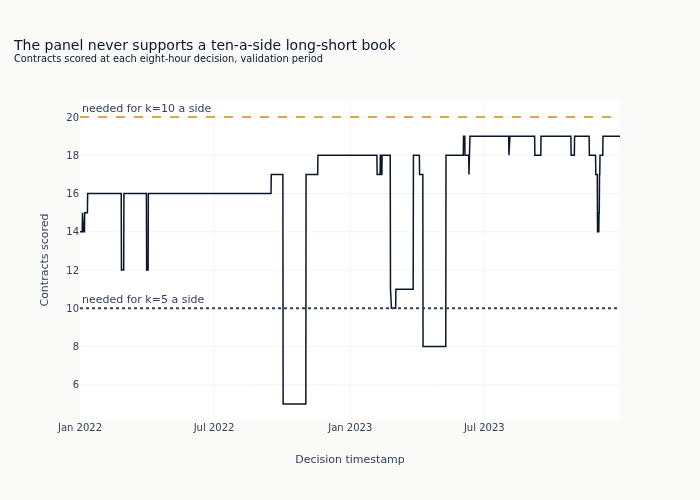

In [14]:
fig_breadth = go.Figure(
    go.Scatter(
        x=breadth.get_column("timestamp").to_list(),
        y=breadth.get_column("len").to_list(),
        mode="lines",
        line={"color": COLORS["blue"], "width": 1.5},
        name="Contracts scored",
    )
)
for k, style in ((5, "dot"), (10, "dash")):
    fig_breadth.add_hline(
        y=2 * k,
        line={"color": COLORS["amber"] if k == 10 else COLORS["neutral"], "dash": style},
        annotation_text=f"needed for k={k} a side",
        annotation_position="top left",
    )
fig_breadth.update_layout(
    title={
        "text": "The panel never supports a ten-a-side long-short book"
        "<br><sup>Contracts scored at each eight-hour decision, validation period</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Decision timestamp",
    yaxis_title="Contracts scored",
    showlegend=False,
)
show_plotly_with_alt(
    fig_breadth,
    "Line chart of the number of perpetual contracts scored at each eight-hour decision over the "
    "validation period, with two horizontal reference lines at ten and twenty contracts marking "
    "what a five-a-side and a ten-a-side long-short book need. The series starts at fourteen "
    "contracts in January 2022 and ends at nineteen, and it never touches the twenty line, so "
    "the ten-a-side rule is never fillable. It drops below the ten line in two separate "
    "episodes rather than trending: to five between 2 October and 2 November 2022, and to eight "
    "between 9 April and 10 May 2023, ninety-three decisions each and 186 of 2,189 in total. "
    "Across those the five-a-side rule truncates to whatever the cross-section holds rather "
    "than failing.",
)

## 4. Running the grid

`run_backtests` takes the selected catalog rows and one entry rule, resolves each into a
complete strategy specification, computes the identity that specification implies, and only then
executes. Resolution is where the case-study specifics enter: the engine configuration from
`config/backtest/base.yaml`, the fee schedule, the fill timing, the price series, and - for this
case study alone - the official funding rates joined to the exact symbol-timestamp pairs the
prices cover. All of it is hashed into the result's identity, so a run whose funding data
changed is a different result rather than the same one with different numbers.

Prices are loaded once per label and passed in. The boundary would load them itself, and loads
the same rows either way, but it would do so twice for every configuration.

Each call publishes an immutable population of exactly the backtests it is about to produce, and
requires every member to exist and be complete afterwards. Re-running the notebook re-derives
the same identities, finds them registered, and returns the stored results rather than
re-executing - so the cost of a second run is reading the data.

In [15]:
config = get_backtest_config("crypto_perps_funding")
print(
    f"Costs: {config.commission_bps:.1f} bps commission and "
    f"{config.slippage_bps:.1f} bps slippage per leg, on {config.initial_cash:,.0f} of capital"
)

Costs: 4.0 bps commission and 1.0 bps slippage per leg, on 100,000 of capital


In [16]:
executions = []
for label in labels:
    prices = load_backtest_prices_for(
        "crypto_perps_funding", label, split="validation", warmup_periods=0
    )
    label_rows = catalog.filter(pl.col("label") == label)
    for scheme in schemes_by_label[label]:
        signal = {key: value for key, value in scheme.items() if key != "name"}
        signal_population = f"crypto-signal-{label}-{scheme['name']}-{POPULATION_SUFFIX}"
        execution = run_backtests(
            study,
            predictions=label_rows,
            signal=signal,
            prices=prices,
            chapter="ch16",
            # A population is canonical by definition and is written to the shared registry
            # whatever tier is active, so a preview run names none and the stages below read
            # its executions directly instead.
            population_name=signal_population if CANONICAL_RUN else None,
            # The declaration is a name, not a hash, so it has to be resolved against the
            # registry before `create` sees it: `create` compares the value it is handed to the
            # generation in force and refuses anything else, and the string "live" is not a
            # hash. `population_supersedes` turns it into the tip, and withholds it where
            # offering it would be refused - a clean clone, a preview, or a name with no
            # generation yet - so a reader still publishes generation one.
            supersedes=(
                population_supersedes(
                    study,
                    name=signal_population,
                    declared=SUPERSEDES_BACKTESTS.get(signal_population),
                )
                if CANONICAL_RUN
                else None
            ),
        )
        executions.append((label, scheme["name"], execution))
        print(
            f"{label} / {scheme['name']}: {len(execution.results)} backtests registered\n"
            f"  this execution: {execution.disclosure()}"
        )

fwd_ret_8h / ew_top3: 262 backtests registered
  this execution: computed all 262


fwd_ret_8h / ew_top5: 262 backtests registered
  this execution: computed all 262


fwd_ret_8h / quintile_ls: 262 backtests registered
  this execution: computed all 262


fwd_ret_24h / ew_top3: 242 backtests registered
  this execution: computed all 242


fwd_ret_24h / ew_top5: 242 backtests registered
  this execution: computed all 242


...

fwd_dir_8h / ew_top5: 86 backtests registered
  this execution: computed all 86


fwd_dir_8h / quintile_ls: 86 backtests registered
  this execution: computed all 86


fwd_dir_8h_3c / ew_top3: 87 backtests registered
  this execution: computed all 87


fwd_dir_8h_3c / ew_top5: 87 backtests registered
  this execution: computed all 87


fwd_dir_8h_3c / quintile_ls: 87 backtests registered
  this execution: computed all 87


### The candidate set each label hands on

A **candidate set** is the population downstream stages are allowed to choose from. Registry
presence is not membership: a result exists in the registry the moment it is written, and the
candidate set is the separate statement admitting it to a comparison. One set per label holds
every baseline for that label, across both entry rules, and
[`14_portfolio_management`](14_portfolio_management.ipynb) opens it by name rather than being
handed a list of hashes.

A candidate set is canonical too - `CandidateSet.create` refuses a preview member - so a
preview run leaves the funnel's named pools alone and the stages downstream read its backtest
catalog directly.

In [17]:
signal_candidate_members: dict[str, list[str]] = {}
for label in labels:
    members = [
        result
        for member_label, _, execution in executions
        if member_label == label
        for result in execution.results
    ]
    candidate_set_name = f"crypto-signal-{label}"
    if CANONICAL_RUN:
        candidates = CandidateSet.create(
            study,
            candidate_set_name,
            members,
            supersedes=candidate_set_supersedes(
                study,
                name=candidate_set_name,
                declared=SUPERSEDES_CANDIDATES.get(candidate_set_name),
            ),
        )
        signal_candidate_members[label] = list(candidates.members)
        print(f"{candidates.name}: {len(candidates.members)} members")
    else:
        signal_candidate_members[label] = [result.hash for result in members]
        print(f"{candidate_set_name} (preview): {len(members)} members, not frozen")

crypto-signal-fwd_ret_8h: 786 members


crypto-signal-fwd_ret_24h: 726 members


crypto-signal-fwd_dir_8h: 258 members


crypto-signal-fwd_dir_8h_3c: 261 members


## 5. What came out

One row per label and entry rule, read back from the registry rather than from the objects the
loop returned. `sharpe` is the annualized ratio of mean daily return to its standard deviation,
on the crypto calendar of 365 days; the median and the spread across configurations describe the
population, and the count of configurations above zero says how much of it made money at all.
`avg_turnover` is the fraction of the book replaced at an average rebalance, which is what the
commission and slippage columns are charged on.

The rows are the ones this run just registered, named by hash, and not every signal-stage row
the registry holds. The registry keeps every generation ever run, so the wider read reports a
retired generation's backtests alongside the live one: the rendered notebook said 346
`fwd_ret_8h` backtests per rule after executing 262, and every median and spread below was
computed over the union.

In [18]:
swept = [result.hash for _, _, execution in executions for result in execution.results]
results = study.backtests.table(include_preview=not CANONICAL_RUN).filter(
    pl.col("backtest_hash").is_in(swept)
)
if results.height != len(swept):
    raise RuntimeError(
        f"{len(swept)} backtests were executed and {results.height} read back from the registry"
    )
if results.filter(~pl.col("complete")).height:
    raise RuntimeError("the signal-stage backtest catalog contains incomplete members")

signal_grid = (
    results.with_columns(
        entry_rule=pl.when(pl.col("signal_method") == "equal_weight_top_k")
        .then(
            pl.lit("top-")
            + pl.col("spec_json").str.json_path_match("$.strategy.signal.top_k")
            + pl.lit(" a side")
        )
        .otherwise(pl.col("signal_method"))
    )
    .group_by("label", "entry_rule")
    .agg(
        backtests=pl.len(),
        median_sharpe=pl.col("sharpe").median(),
        min_sharpe=pl.col("sharpe").min(),
        max_sharpe=pl.col("sharpe").max(),
        above_zero=(pl.col("sharpe") > 0).sum(),
        median_turnover=pl.col("avg_turnover").median(),
        median_trades=pl.col("num_trades").median(),
    )
    .sort("label", "entry_rule")
)
signal_grid

label,entry_rule,backtests,median_sharpe,min_sharpe,max_sharpe,above_zero,median_turnover,median_trades
str,str,u32,f64,f64,f64,u32,f64,f64
"""fwd_dir_8h""","""quintile_long_short""",86,-2.727196,-3.830761,-0.92224,0,4.089726,9097.5
"""fwd_dir_8h""","""top-3 a side""",86,-2.723467,-3.732141,-0.974433,0,4.113014,9782.0
"""fwd_dir_8h""","""top-5 a side""",86,-3.061569,-4.246353,-1.030154,0,4.47589,13658.5
"""fwd_dir_8h_3c""","""quintile_long_short""",87,-1.604901,-2.997457,-0.646291,0,3.345205,8695.0
"""fwd_dir_8h_3c""","""top-3 a side""",87,-1.780595,-2.827592,-0.578033,0,3.390411,9385.0
…,…,…,…,…,…,…,…,…
"""fwd_ret_24h""","""top-3 a side""",242,0.216265,-2.134117,1.53199,151,2.83059,3270.5
"""fwd_ret_24h""","""top-5 a side""",242,0.137312,-1.701223,1.308563,146,3.18738,4600.0
"""fwd_ret_8h""","""quintile_long_short""",262,-1.941811,-3.420977,0.486704,11,4.073973,8994.5


**`entry_rule` is what was requested, not what every decision traded.** The label is read from
`strategy.signal.top_k` in the registered specification, so a `top-5 a side` row is named for the
book it asked for. The allocator takes `min(k, n/2)` at each decision, so how often the name
overstates the book depends on `k` and not only on the panel:

- **`top-5 a side` narrows at 186 of the decisions** - both sub-ten episodes, because five a
  side needs ten names and the panel holds five in the first and eight in the second.
- **`top-3 a side` narrows at 93** - only the five-contract episode. Where the panel holds
  eight, `min(3, 4)` is 3 and a three-a-side book fills exactly as named.
- The quantile rule takes a fraction of whatever is quoted, so it has no fixed width to fall
  short of and is not affected.

The counts are the same for all four labels: every one predicts on the same eight-hour decision
grid, and `fwd_ret_24h` differs only in how long a position is then held, not in when it is
opened. `fwd_ret_24h` has 2,187 decisions to the others' 2,189, which is its longer horizon
retiring the last two of each fold.

This is a caveat on reading the table, not a defect in the results. Within a label every
configuration met the same cross-section on the same dates, so the comparison between rows holds
even where the name overstates the book.

### The spread the baseline produces

One panel per label, one distribution per entry rule, over every configuration that label
declared. The zero line is the reference: a point below it is a configuration whose ranking,
traded equally weighted and charged the declared costs and the funding it actually paid, lost
money over the validation period.

Read the *width* rather than the extreme. Every configuration in a panel saw the same contracts
over the same timestamps, so the spread within a panel is what changing the model does at fixed
sizing, and it is the quantity the later stages have to beat to be worth their extra machinery.
A panel's highest point is the largest of many draws, and how much of it is the draw rather than
the model is what [`19_strategy_analysis`](19_strategy_analysis.ipynb) accounts for.

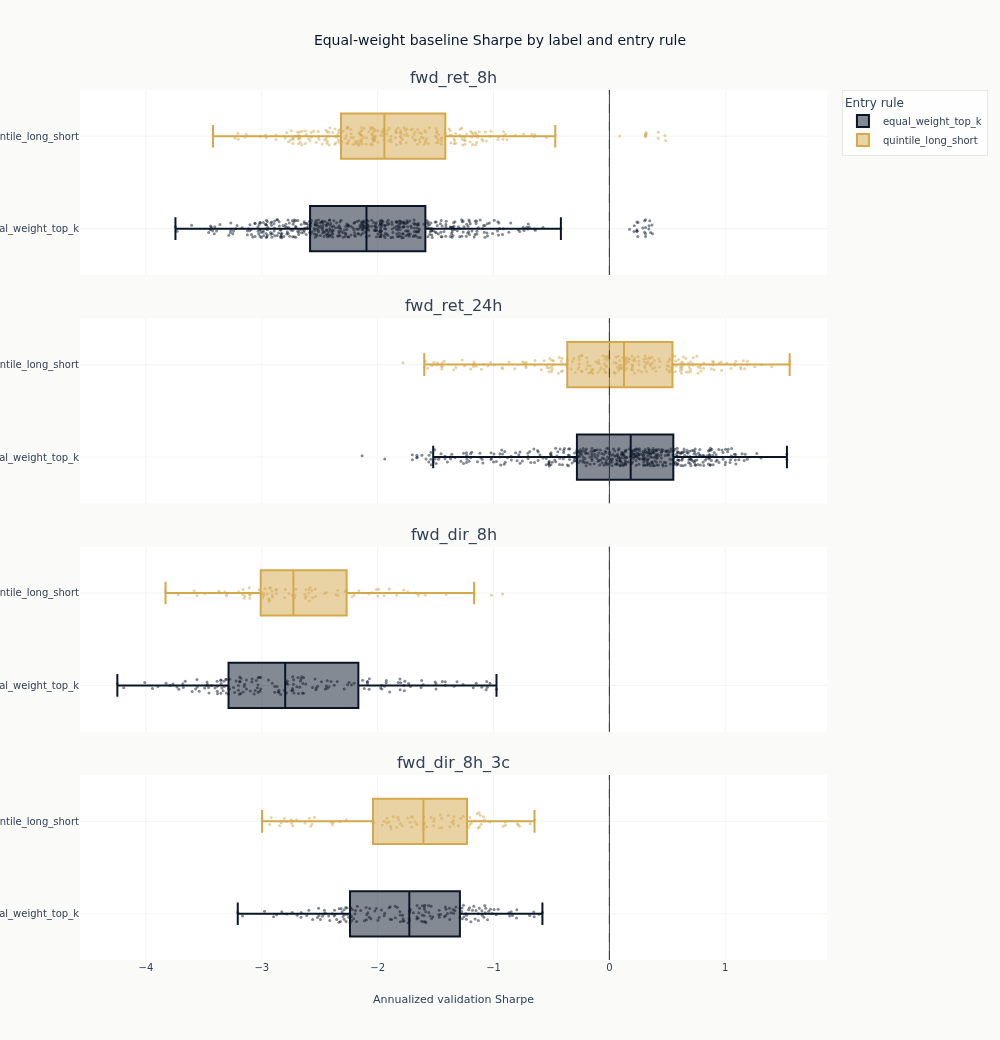

In [19]:
panel_labels = [label for label in labels if results.filter(pl.col("label") == label).height]
fig_spread = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=panel_labels,
)
rules = sorted(set(results.get_column("signal_method")))
for row, label in enumerate(panel_labels, start=1):
    for rule, color in zip(rules, (COLORS["blue"], COLORS["amber"]), strict=False):
        panel = results.filter((pl.col("label") == label) & (pl.col("signal_method") == rule))
        fig_spread.add_trace(
            go.Box(
                x=panel.get_column("sharpe").to_list(),
                name=rule,
                marker_color=color,
                boxpoints="all",
                jitter=0.4,
                pointpos=0,
                marker={"size": 3, "opacity": 0.5},
                showlegend=row == 1,
            ),
            row=row,
            col=1,
        )
    fig_spread.add_vline(
        x=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
fig_spread.update_xaxes(title_text="Annualized validation Sharpe", row=len(panel_labels), col=1)
fig_spread.update_layout(
    title="Equal-weight baseline Sharpe by label and entry rule",
    height=260 * len(panel_labels),
    width=1000,
    legend_title="Entry rule",
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig_spread,
    "Box plots with every configuration overlaid as a point, one panel per prediction label and "
    "one box per entry rule within each panel, showing annualized validation Sharpe. Each panel "
    "carries a dashed vertical line at zero. The distributions straddle zero in every panel and "
    "the two entry rules overlap heavily within each label, so neither rule separates from the "
    "other and no label separates from the rest.",
)

## 6. What to notice

**An equal-weight baseline is a measuring instrument, not a candidate.** It exists so that the
stages after it can change exactly one thing and attribute the difference. Sizing changes in
`14_portfolio_management`, the cost assumption in [`16_costs`](16_costs.ipynb), an exit overlay
in [`15_risk_management`](15_risk_management.ipynb) - each against the same rankings, the same
timestamps and the same funding. A comparison that changes the model *and* the sizing measures
neither.

**The funding settlement is inside the identity, which is what makes the later comparisons
possible.** Nothing here reconstructs the equity curve afterwards to add funding on top. Had it
done so, the registered return and the funding-adjusted return would be two different series
with one hash between them, and every downstream stage would have to be told which one it was
reading. Because the settlement happens in the engine, the registered return, the turnover and
the drawdown all describe the same book.

**A grid member the cross-section cannot fill is a declaration problem, not a result.** The
ten-a-side rule is in `setup.yaml` and is never run, and the count of what was requested against
what executed is in the notebook for that reason. The alternative - letting the engine take
whatever names are available and calling it a ten-a-side book - produces a result that is
reported under a name it does not match.

**Two folds, and a cross-section under twenty.** Each Sharpe above is estimated from two
validation years on a panel that starts thinner than it ends. The spread within a panel is
therefore wide for reasons that have nothing to do with the models, and a difference of the
same size as that spread is not evidence of anything.

**Known limitations.** The baseline charges a flat commission and slippage to every contract,
while the fee schedule this exchange publishes separates the largest contracts from the rest;
`16_costs` is where that assumption is varied rather than assumed away. Positions are held for
exactly the label horizon with no exit condition, which `15_risk_management` relaxes. And every
number here is measured on the validation folds, which the case study has read many times by the
time it reaches this notebook.

**Next**: [`14_portfolio_management`](14_portfolio_management.ipynb) keeps the rankings and the
entry rules fixed and varies how much capital each admitted position gets.